Phase 5

In [1]:
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer


In [2]:
# Load the embeddings and chunks from the file
data = np.load('../data/embeddings/gfg_embeddings.npz', allow_pickle=True)
embeddings = data['embeddings']
chunks = data['chunks']

In [7]:
embeddings

array([[-0.07246457, -0.02648632, -0.0125813 , ...,  0.1020965 ,
         0.12133171,  0.04427522],
       [-0.0580874 ,  0.02773986,  0.02308076, ...,  0.06691647,
         0.04825249, -0.01131586],
       [-0.00773718,  0.00902082,  0.01810016, ...,  0.13310744,
         0.05725064,  0.04777288],
       ...,
       [ 0.00296008,  0.00946421,  0.07496109, ..., -0.04386897,
         0.05921075,  0.05533337],
       [ 0.05260039,  0.03744986,  0.02273124, ..., -0.04092132,
         0.04312694,  0.02450054],
       [-0.00134087,  0.00560886, -0.09902793, ...,  0.06729648,
         0.01155774,  0.02333897]], dtype=float32)

In [9]:
chunks

array(['Python Tutorial | Learn Python Programming Language Last Updated : 18 Apr, 2025 Comments Improve Suggest changes Like Article Like Report Python Tutorial – Python is one of the most popular programming languages. It’s simple to use, packed with features and supported by a wide range of libraries and frameworks. Its clean syntax makes it beginner-friendly. Python is: A high-level language, used in web development, data science, automation, AI and more. Known for its readability, which means code is easier to write, understand and maintain. Backed by library support, so we don’t have to build everything from scratch, there’s probably a library that already does what we need. Why to Learn Python? Python requires fewer lines of code compared to other programming languages. Python is in high demand as it provides many job opportunities in Software Development, Data Science and AI/ML. Python provides popular Web Development, AI/ML, Data Science and Data Analysis Libraries like Django

### FAISS index using L2

In [32]:
# Create FAISS index
dimension = embeddings.shape[1]  # e.g., 384 for all-MiniLM-L6-v2
index_l2 = faiss.IndexFlatL2(dimension)
index_l2.add(embeddings)
print(f"✅ FAISS index created with {index_l2.ntotal} vectors.")

✅ FAISS index created with 517 vectors.


In [35]:
model = SentenceTransformer('all-MiniLM-L6-v2')
question = "What is deep learning?"
question_embedding = model.encode(question, convert_to_tensor=False)
question_embedding = np.array([question_embedding]).astype('float32')

# Normalize if using cosine similarity
faiss.normalize_L2(question_embedding)

# Search the index (k=3 retrieves top 3 chunks)
k = 10
distances, indices = index_l2.search(question_embedding, k)

print("Top 3 matching chunk indices:", indices[0])
print("Distances (lower is better):", distances[0])

Top 3 matching chunk indices: [398 178 397  77  20 177 320 251 357 359]
Distances (lower is better): [0.6237944  0.839345   0.85530365 0.90883684 0.97872764 1.0744209
 1.1193144  1.1207744  1.1273813  1.1282718 ]


In [ ]:
chunks[178]

'more Computer Subject Python-Quizzes Machine Learning python Deep Learning AI-ML-DS AI-ML-DS With Python What is LSTM - Long Short Term Memory? Last Updated: 05 April 2025 Long Short-Term Memory (LSTM) is an enhanced version of the Recurrent Neural Network (RNN) designed by Hochreiter Schmidhuber. LSTMs can ca ...read more Computer Subject Machine Learning Deep Learning AI-ML-DS Generative Adversarial Network (GAN) Last Updated: 10 March 2025 Generative Adversarial Networks (GANs) were introduced by Ian Goodfellow and his colleagues in 2014. GANs are a class of neural networks tha ...read more Technical Scripter Python Python-Quizzes python Deep Learning AI-ML-DS Introduction to Recurrent Neural Networks Last Updated: 11 February 2025 Recurrent Neural Networks (RNNs) work a bit different from regular neural networks. In neural network the information flows in one direction ...read more Neural Network Deep Learning AI-ML-DS AI-ML-DS With Python Introduction to Deep Learning Last Update

### FAISS index using Cosine similarity

In [39]:
# Create FAISS index
dimension = embeddings.shape[1]  # e.g., 384 for all-MiniLM-L6-v2
index = faiss.IndexFlatIP(dimension)
faiss.normalize_L2(embeddings)
index.add(embeddings)
print(f"FAISS index created with {index.ntotal} vectors.")

FAISS index created with 517 vectors.


In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')
question = "What is deep learning?"
question_embedding = model.encode(question, convert_to_tensor=False)
question_embedding = np.array([question_embedding]).astype('float32')

# Normalize if using cosine similarity
faiss.normalize_L2(question_embedding)

# Search the index (k=3 retrieves top 3 chunks)
k = 10
similarity, indices = index.search(question_embedding, k)

print("Top 3 matching chunk indices:", indices[0])
print("Distances (lower is better):", similarity[0])

Top 3 matching chunk indices: [398 178 397  77  20 177 320 251 357 359]
Distances (lower is better): [0.68810284 0.5803275  0.57234824 0.5455816  0.5106362  0.4627896
 0.44034278 0.4396128  0.4363094  0.43586403]


In [31]:
chunks[398]  # Corresponding chunk for the first embedding

', PegasusTokenizer # Pick model model_name = "google/pegasus-xsum" # Load pretrained tokenizer pegasus_tokenizer = PegasusTokenizer . from_pretrained ( model_name ) example_text = """ Deep learning (also known as deep structured learning) is part of a broader family of machine learning methods based on artificial neural networks with representation learning. Learning can be supervised, semi-supervised or unsupervised. Deep-learning architectures such as deep neural networks, deep belief networks, deep reinforcement learning, recurrent neural networks and convolutional neural networks have been applied to fields including computer vision, speech recognition, natural language processing, machine translation, bioinformatics, drug design, medical image analysis, material inspection and board game programs, where they have produced results comparable to and in some cases surpassing human expert performance. Artificial neural networks (ANNs) were inspired by information processing and distr

### Save .faiss

In [41]:
# Save index and chunks
faiss.write_index(index, "../data/embeddings/vector_index_CS.faiss")
np.save("../data/processed/text_chunks.npy", chunks)

print("💾 Index and chunks saved successfully!")

💾 Index and chunks saved successfully!


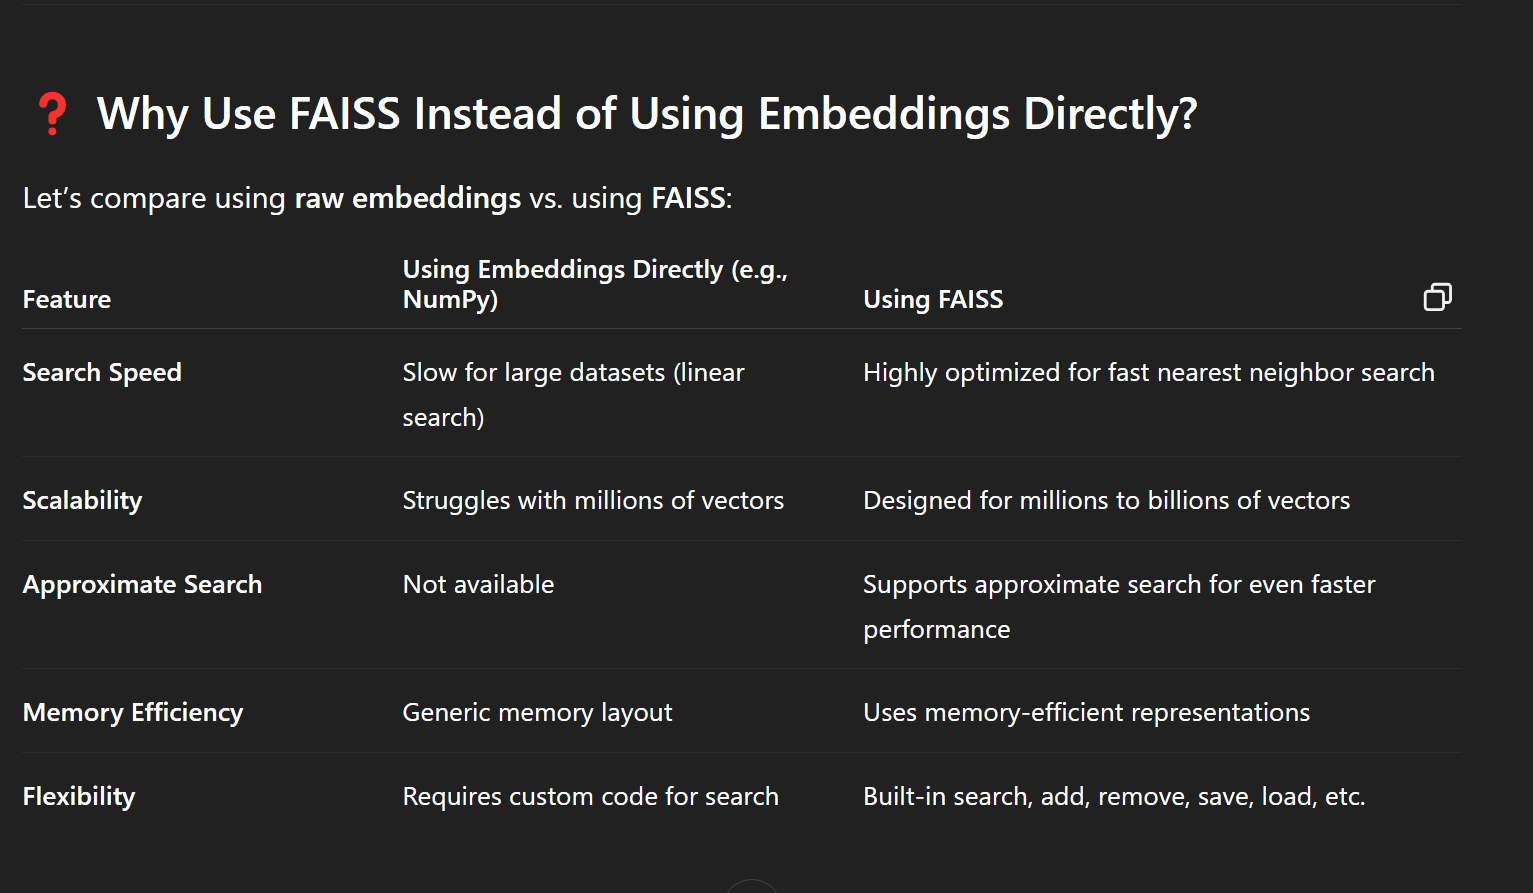

-------------

Phase 6

In [ ]:
import re
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
from transformers import pipeline


In [ ]:
# Load model, index, and chunks
model = SentenceTransformer('all-MiniLM-L6-v2')
index = faiss.read_index("D:\\RAG chatbot\data\\embeddings\\vector_index_CS.faiss")
chunks = np.load("D:\\RAG chatbot\\data\\processed\\text_chunks.npy", allow_pickle=True)
model = SentenceTransformer('all-MiniLM-L6-v2')
generator = pipeline('text-generation', model='gpt2')


In [ ]:
def retrieve_relevant_chunks(question, index, chunks, k=1):
    # Embed the question
    question_embedding = model.encode(question, convert_to_tensor=False)
    question_embedding = np.array([question_embedding]).astype('float32')

    # Normalize if using cosine similarity
    faiss.normalize_L2(question_embedding)
    
    # Search the index
    similarities, indices = index.search(question_embedding, k)
    
    # Retrieve the relevant chunks
    relevant_chunks = [chunks[i] for i in indices[0]]
    return relevant_chunks

def generate_answer(question, relevant_chunks):
    # Combine the context
    context = "\n\n".join(relevant_chunks)
    
    # Create prompt
    prompt = f"""Context: {context}
    
    Question: {question}
    
    Answer:"""
    
    # Generate answer
    answer = generator(
        prompt,
        max_length=1000,
        num_return_sequences=1,
        temperature=0.7,
        truncation=True
    )
    
    return answer[0]['generated_text'].split("Answer:")[-1].strip()

def rag_chatbot(question):
    # Retrieve relevant chunks
    relevant_chunks = retrieve_relevant_chunks(question, index, chunks)
    
    # Generate answer
    answer = generate_answer(question, relevant_chunks)
    
    return answer, relevant_chunks

# Test the chatbot
question = "What is data structure?"
answer, relevant_chunks = rag_chatbot(question)
print(f"Question: {question}")
print(f"Answer: {answer}")

Device set to use cpu
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Question: What is data structure?
Answer: Data structures are the way we think about the world and our world. Data structure is how we organize our data. For example, you can think of data as a collection of numbers. Each individual number represents a unique resource. There are three different types of data:

Text, Memory, and Text. Every cell of a cell represents a resource. Each cell contains information about the cell's characteristics and its storage. Each cell contains a set of values for that resource. It is important to understand that the cell is used to store data and to represent the data. You can store information about the cell's characteristics and storage in a set of values (called the cells). For example, for a cell containing the value "1" the cell contains the value "1.1" and the "1" is a storage resource. This resource is stored in a set of values (called the cells).

Data, Memory, and Memory is the set of values that represent the information that is stored in a cel

In [46]:
relevant_chunks

['learn about data organization and representation in this chapter. Data handling is the process of organizing data systematically. There are a total of three exercises in the Class 8 Maths NCERT Solutions Chapter 5 Exercises with some extra questions. Class 8 Students can access their solutions from the links given here. Class 8 NCERT Solutions Maths Chapter 5 No Of Questions Ex 5.1 5 Questions (5 Short Answers) Ex 5.2 5 Questions (3 Long Answers, 2 Short Answers) Ex 5.3 6 Questions (2 Long Answers, 4 Short Answers) This chapter consists of only three exercises. Exercise 5.1 is based on the basic concept of representing, organizing, and grouping the data provided while Exercise 5.2 helps to make a pie chart for the given data. Moreover, Exercise 5.3 covers the topic that helps to understand the basic concept of probability. Note : Explore more useful resources like data handling notes and data handling formulas to boost your data Handling concepts. Helpful Resources CBSE Class 8 Maths